In [1]:
from pathlib import Path

import numpy as np
from matplotlib import pyplot as plt

import lsstypes as types
from clustering_statistics import tools, box_tools

stats_dir = Path('/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe')

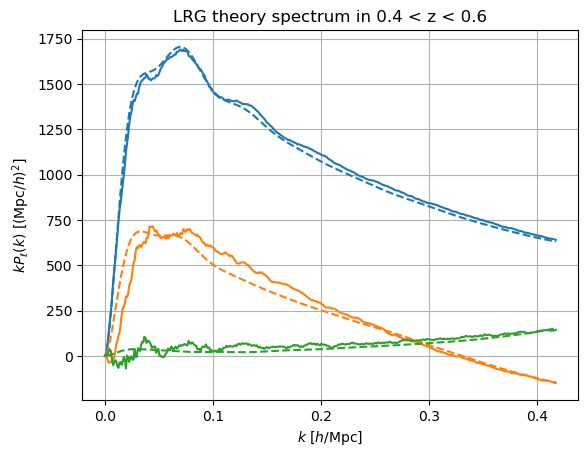

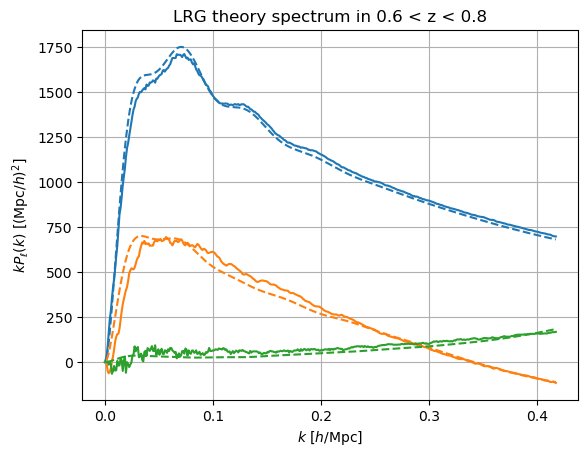

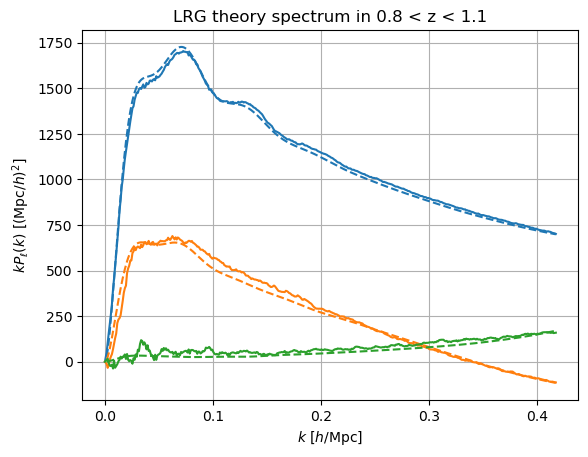

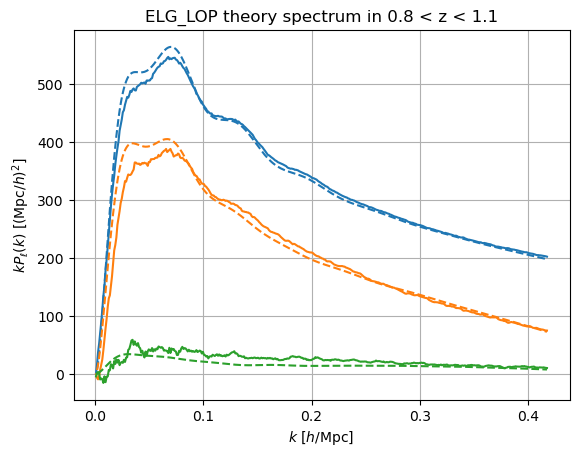

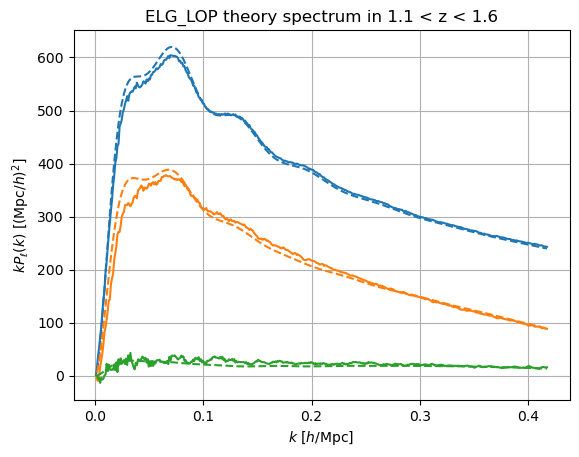

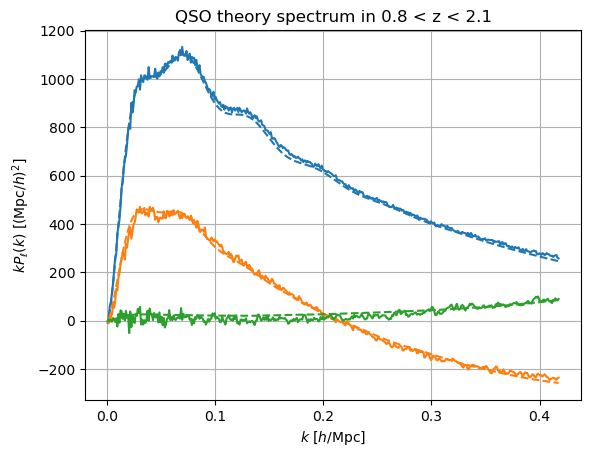

In [2]:
for tracer in ['LRG', 'ELG_LOP', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        kind = 'mesh2_spectrum'
        region = 'NGC'
        fn = tools.get_stats_fn(stats_dir=stats_dir, kind='theory_mesh2_spectrum_poles', version='abacus-2ndgen-complete', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock=0)
        theory = types.read(fn)
        fns = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='abacus-2ndgen-complete', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock='*')
        mean = types.mean([types.read(fn) for fn in fns])
        fig, ax = plt.subplots()
        ax.set_title(f'{tracer} theory spectrum in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for ill, ell in enumerate(theory.ells):
            color = f'C{ill:d}'
            pole = mean.get(ells=ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='-')
            pole = theory.get(ells=ell)
            ax.plot(k:=pole.coords('k'), k * pole.value(), color=color, linestyle='--')
        ax.set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
        ax.set_ylabel(r'$k P_\ell(k)$ [$(\mathrm{{Mpc}}/h)^2$]')
        ax.grid(True)
        plt.show()

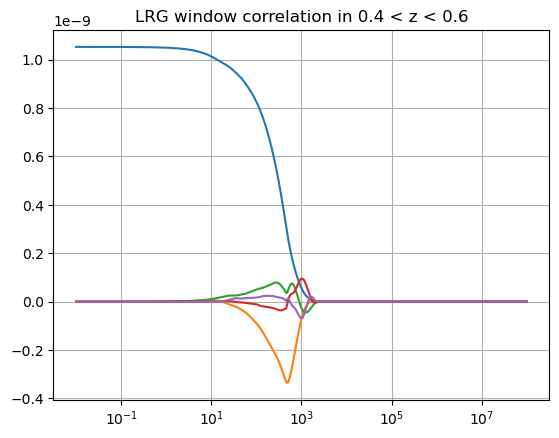

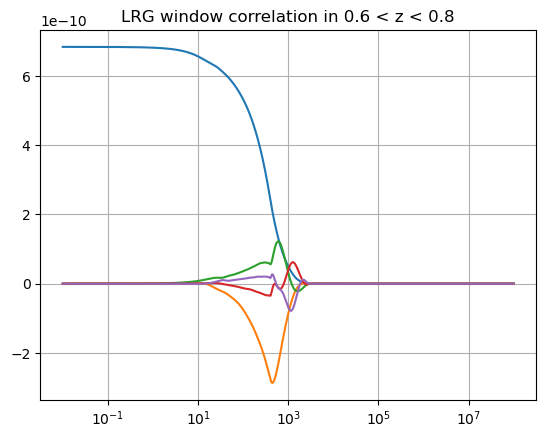

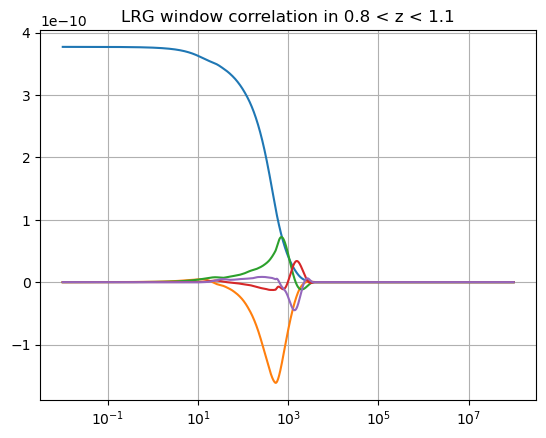

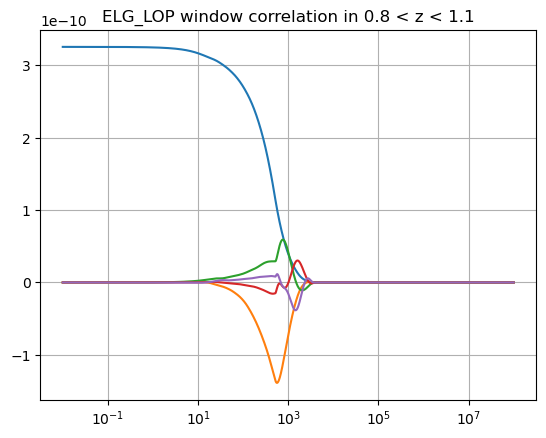

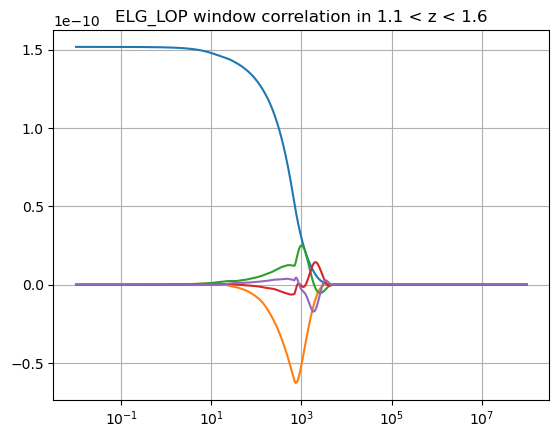

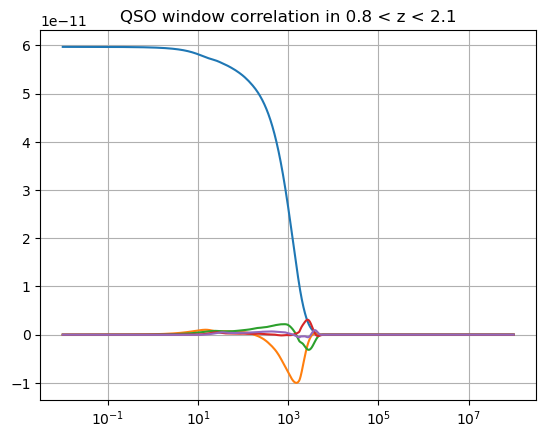

In [3]:
for tracer in ['LRG', 'ELG_LOP', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        kind = 'mesh2_spectrum'
        region = 'SGC'
        fn = tools.get_stats_fn(stats_dir=stats_dir, kind=f'window_covariance_mesh2_correlation', version='abacus-2ndgen-complete', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock=0)
        correlation = types.read(fn).get(types='WW')
        correlation = next(iter(correlation))
        fig, ax = plt.subplots()
        ax.set_title(f'{tracer} window correlation in {zrange[0]:.1f} < z < {zrange[1]:.1f}')
        for pole in correlation:
            #pole = pole.select(s=(1e3, 1e4))
            ax.plot(s:=pole.coords('s'), pole.value())
        ax.set_xscale('log')
        ax.grid(True)
        plt.show()

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/covariance_mesh2_spectrum_poles_LRG_z0.4-0.6_NGC_weight-default-FKP_0.h5


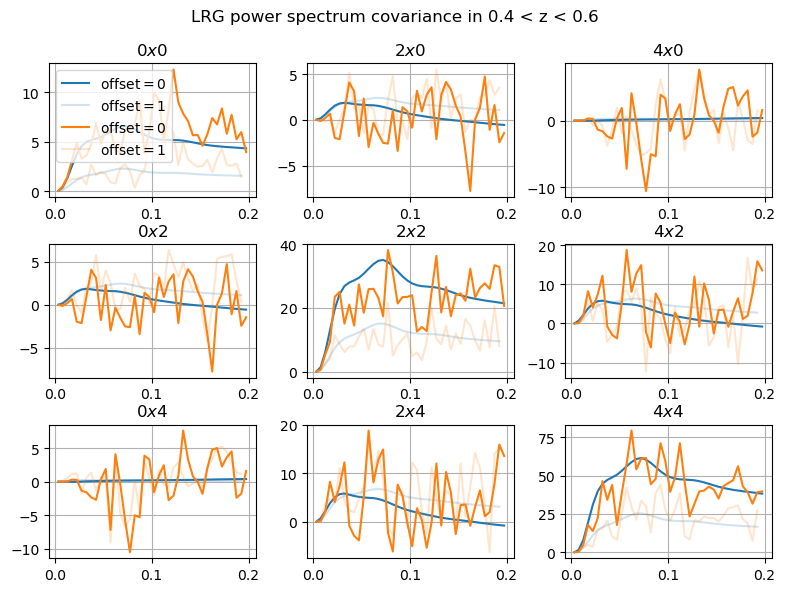

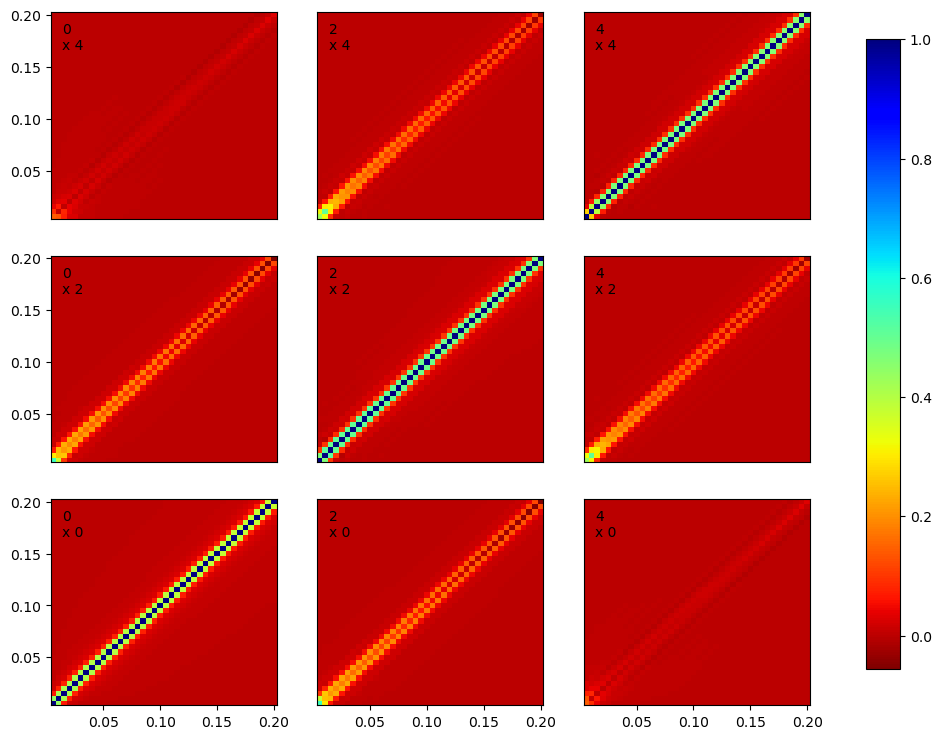

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/covariance_mesh2_spectrum_poles_LRG_z0.6-0.8_NGC_weight-default-FKP_0.h5


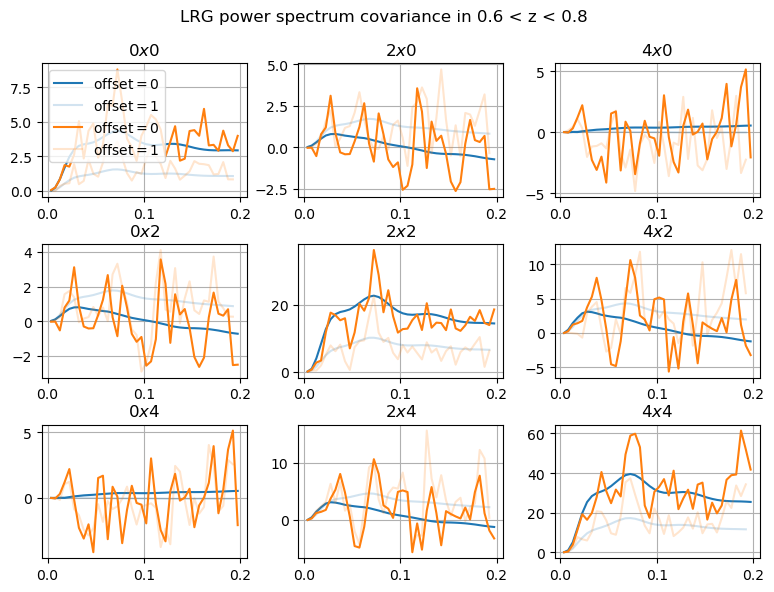

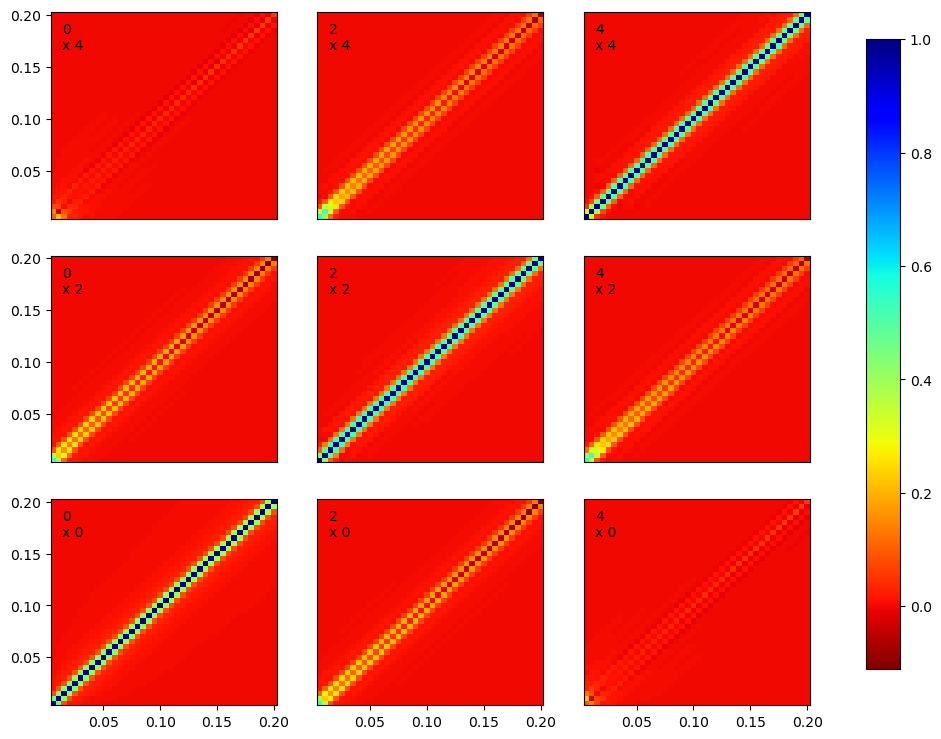

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/covariance_mesh2_spectrum_poles_LRG_z0.8-1.1_NGC_weight-default-FKP_0.h5


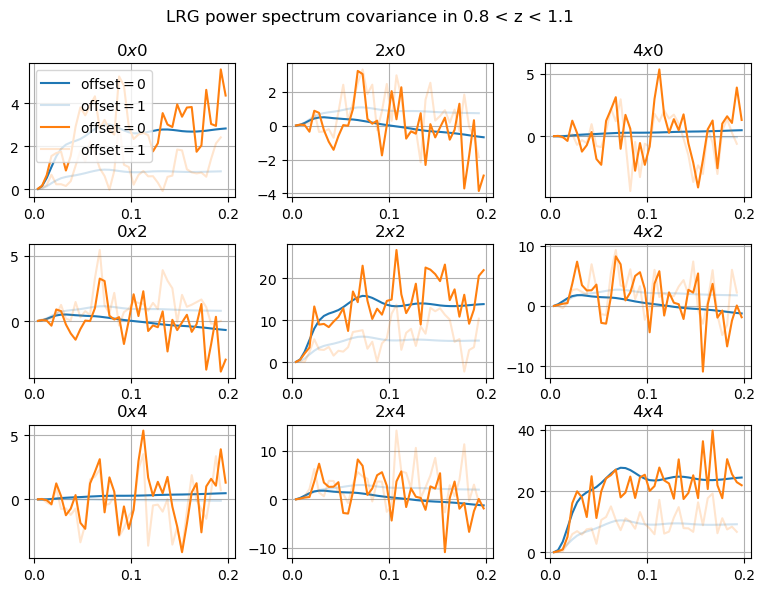

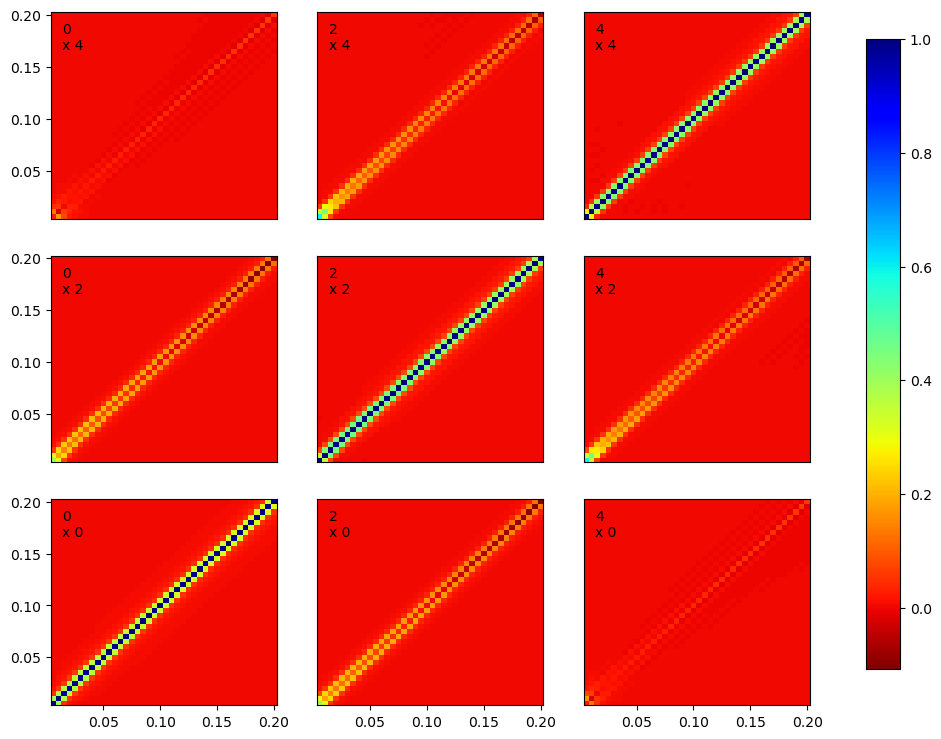

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/covariance_mesh2_spectrum_poles_ELG_LOP_z0.8-1.1_NGC_weight-default-FKP_0.h5


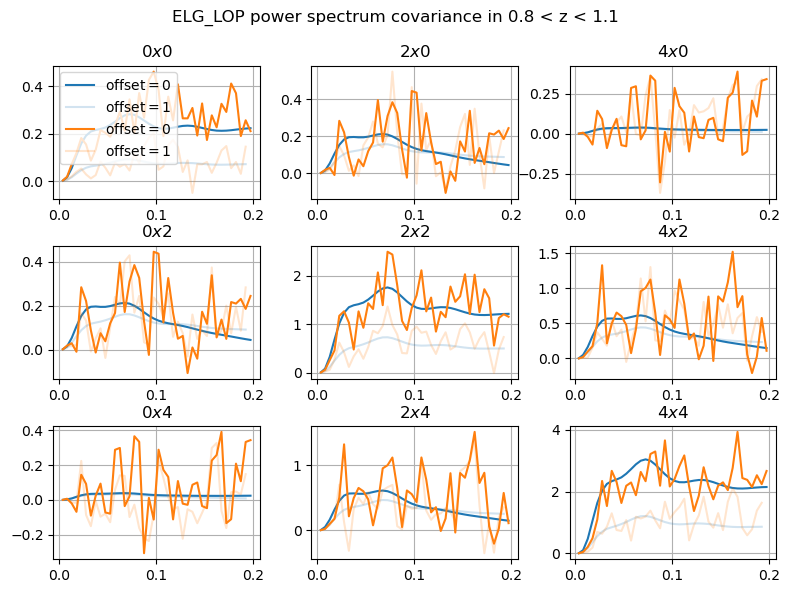

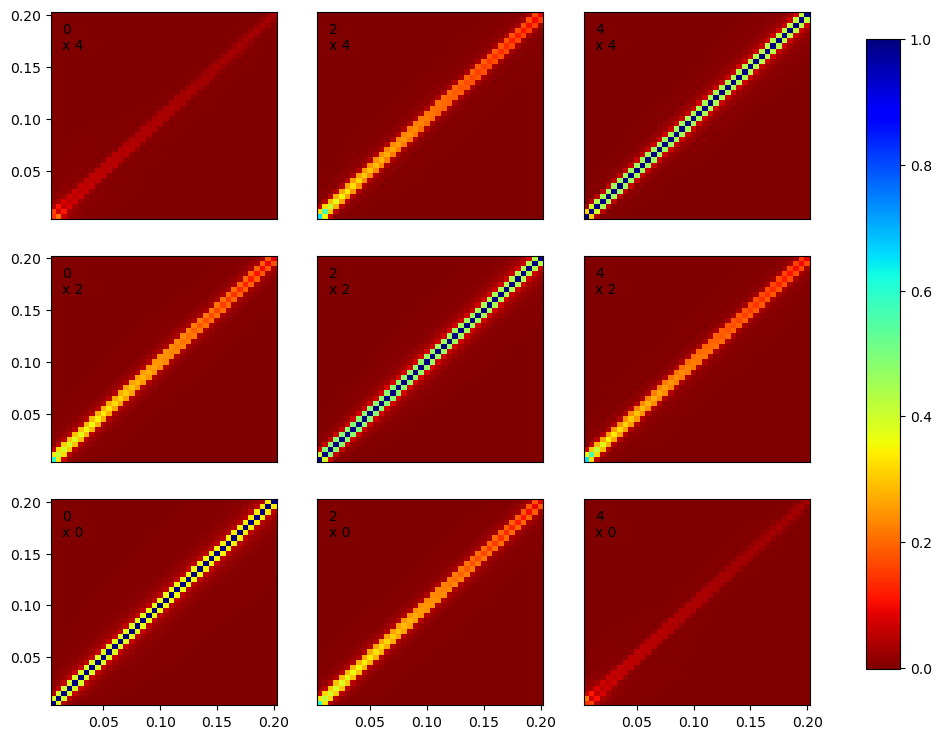

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/covariance_mesh2_spectrum_poles_ELG_LOP_z1.1-1.6_NGC_weight-default-FKP_0.h5


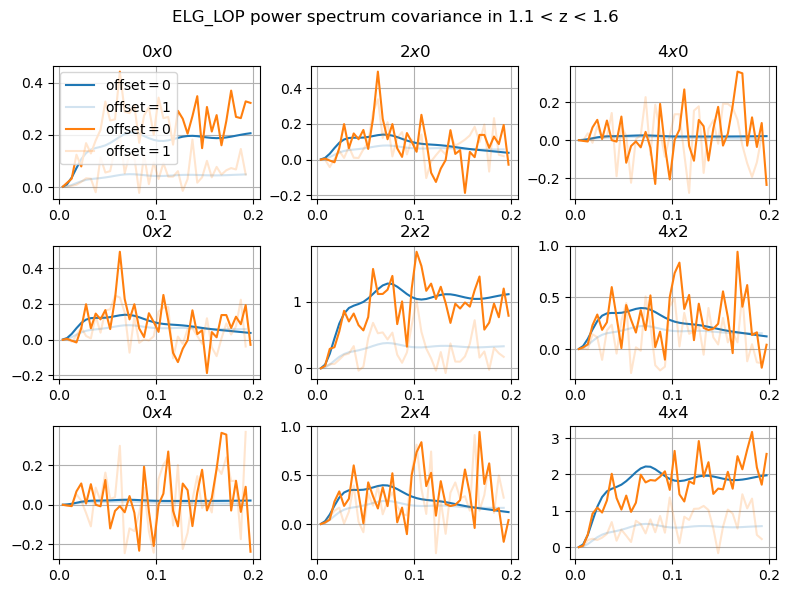

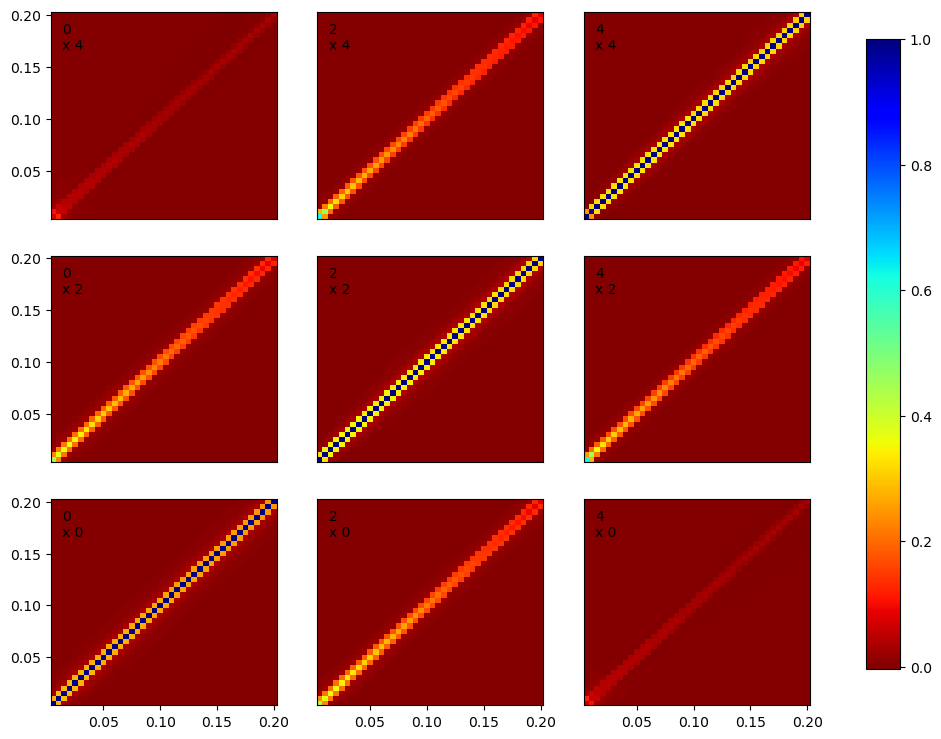

/dvs_ro/cfs/cdirs/desi/mocks/cai/LSS/DA2/mocks/desipipe/abacus-2ndgen-complete/covariance_mesh2_spectrum_poles_QSO_z0.8-2.1_NGC_weight-default-FKP_0.h5


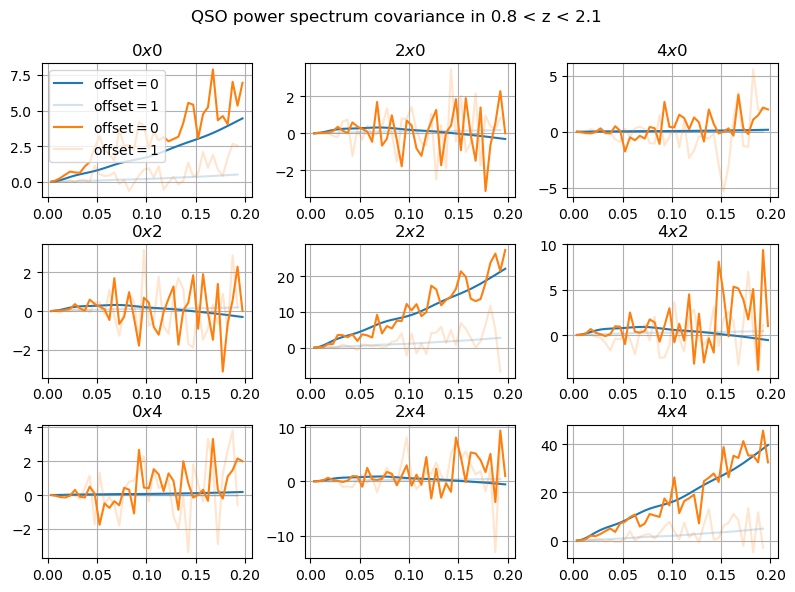

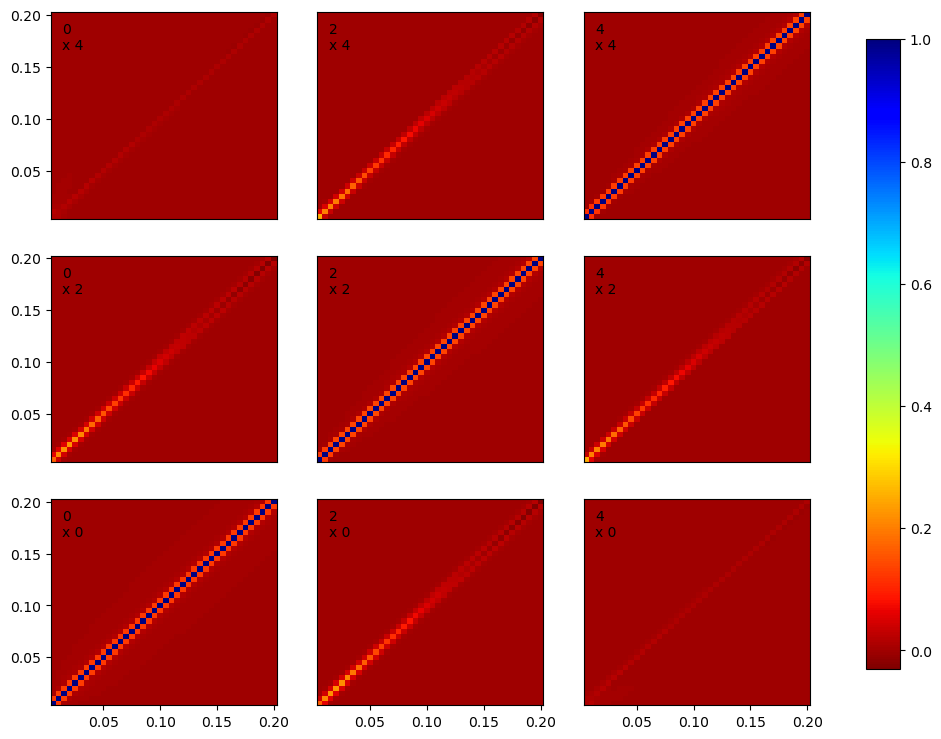

In [4]:
for tracer in ['LRG', 'ELG_LOP', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        kind = 'mesh2_spectrum'
        region = 'NGC'
        fn = tools.get_stats_fn(stats_dir=stats_dir, kind=f'covariance_{kind}', version='abacus-2ndgen-complete', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock=0)
        print(fn)
        covariance_analytic = types.read(fn)
        covariance_analytic = covariance_analytic.at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
        fns = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='abacus-2ndgen-complete', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock='*')
        #mocks = [types.read(fn) for fn in fns]
        #sns = [mock.get(ells=0).values('shotnoise').mean() for mock in mocks]
        #print(np.mean(sns), np.std(sns))
        covariance_mocks = types.cov([types.read(fn) for fn in fns])
        observable = covariance_mocks.observable.select(k=slice(0, None, 5)).select(k=(0., 0.2))
        covariance_analytic = covariance_analytic.at.observable.match(observable)
        covariance_mocks = covariance_mocks.at.observable.match(observable)
        kw = dict(ytransform=lambda x, y: x**4 * y, offset=np.arange(2))
        fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
        fig.suptitle(f'{tracer} power spectrum covariance in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
        covariance_mocks.plot_diag(**kw, fig=fig, color='C1', show=True)
        covariance_analytic.plot(corrcoef=True, show=True)
        #covariance_analytic.plot_slice(0.1, yscale='log', show=True)

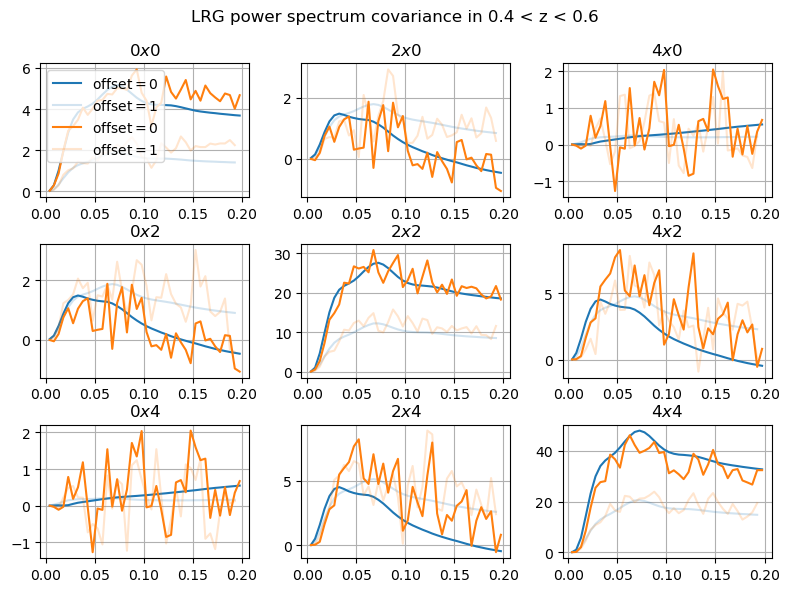

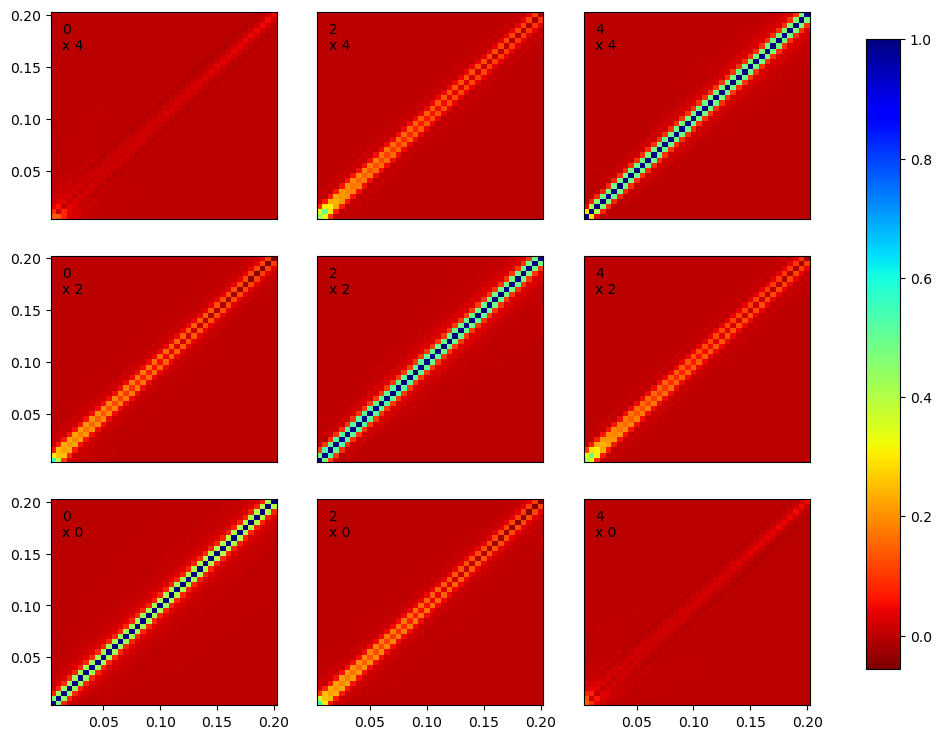

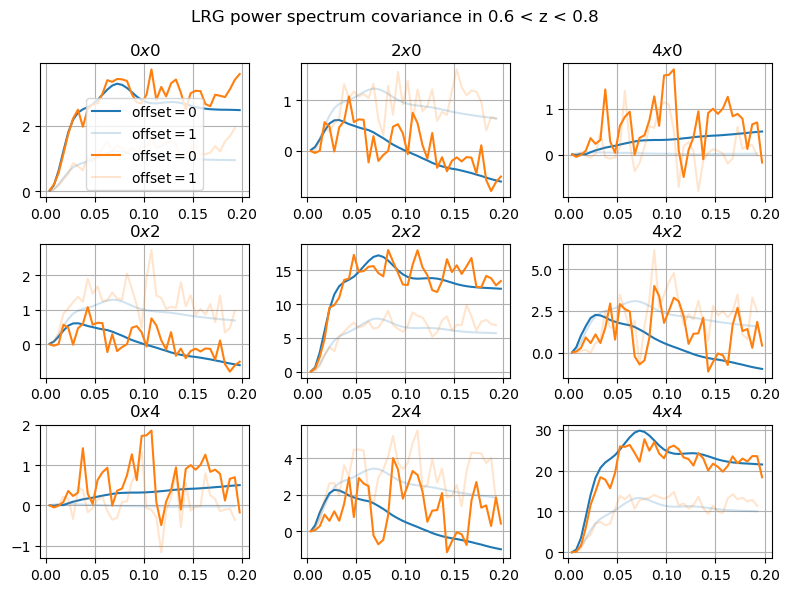

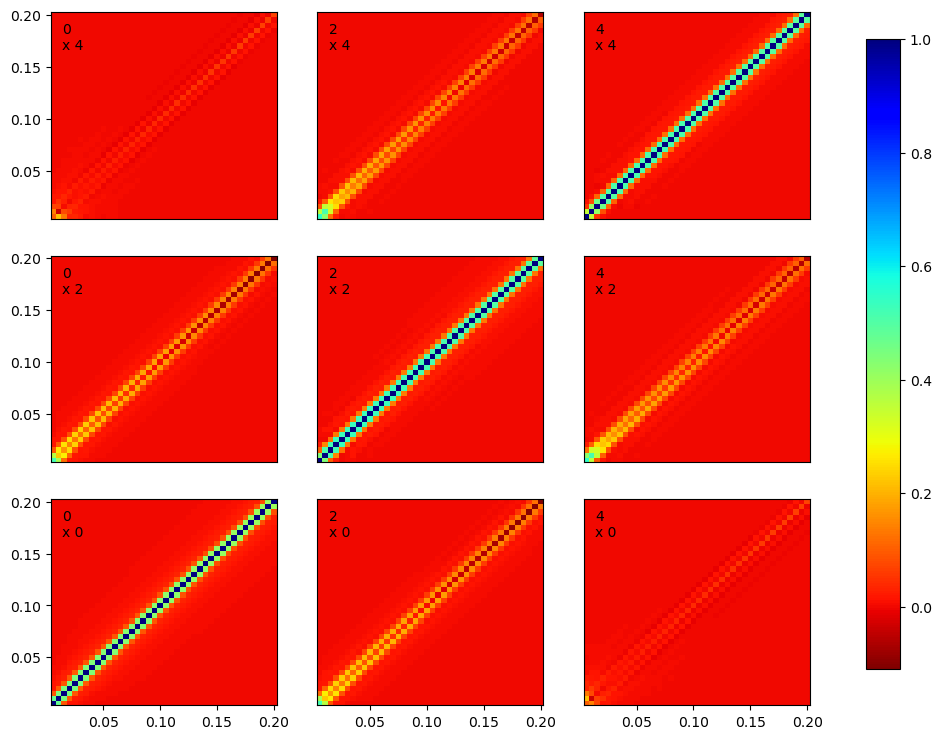

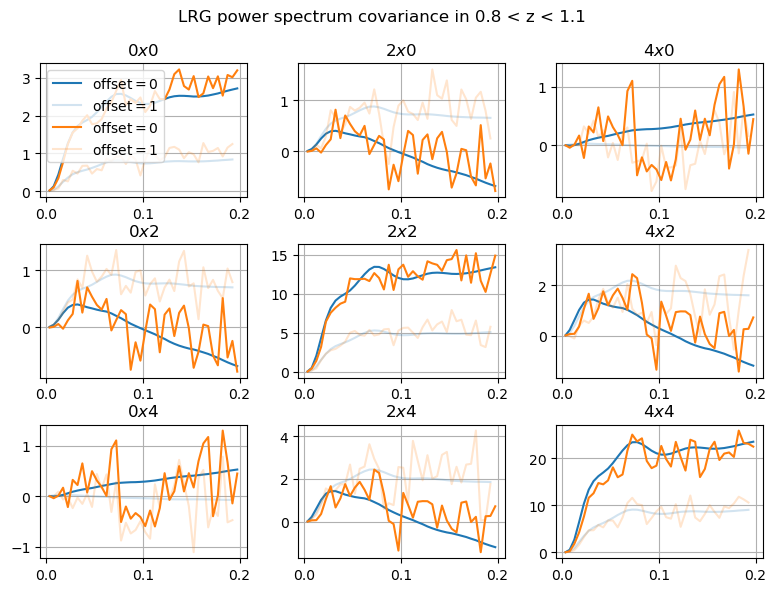

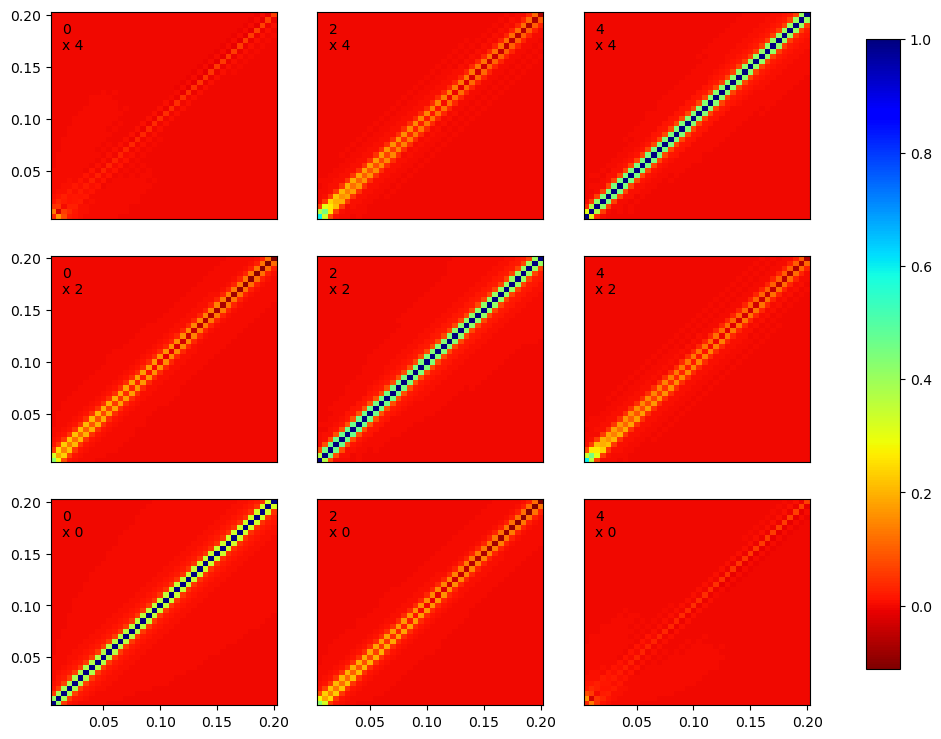

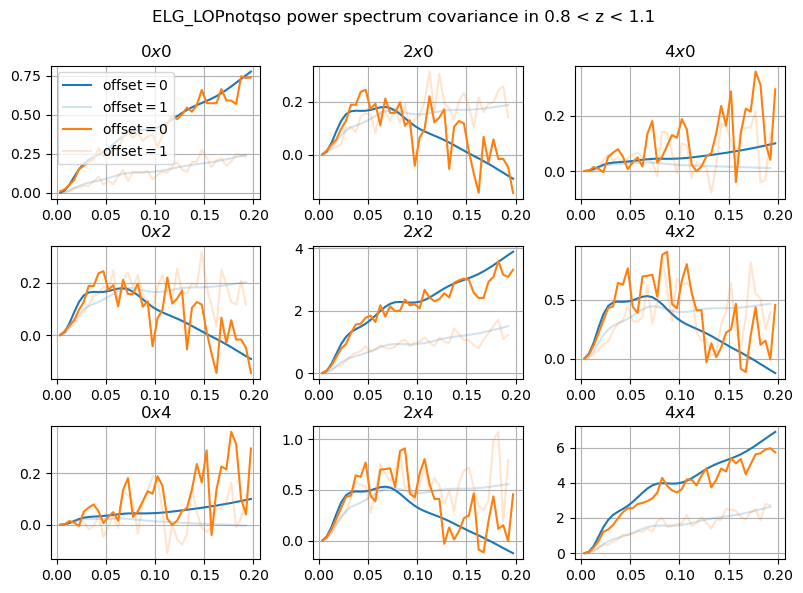

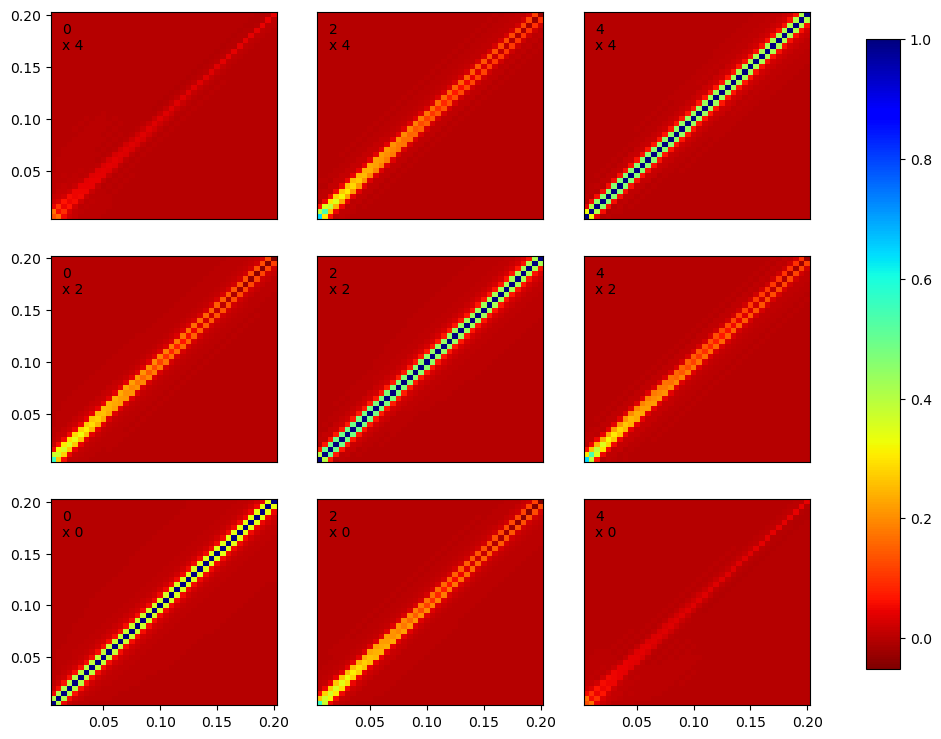

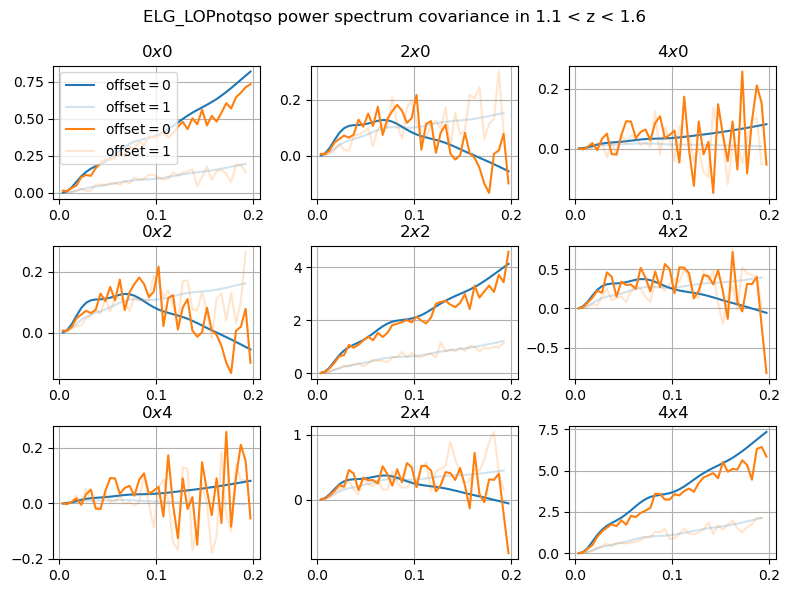

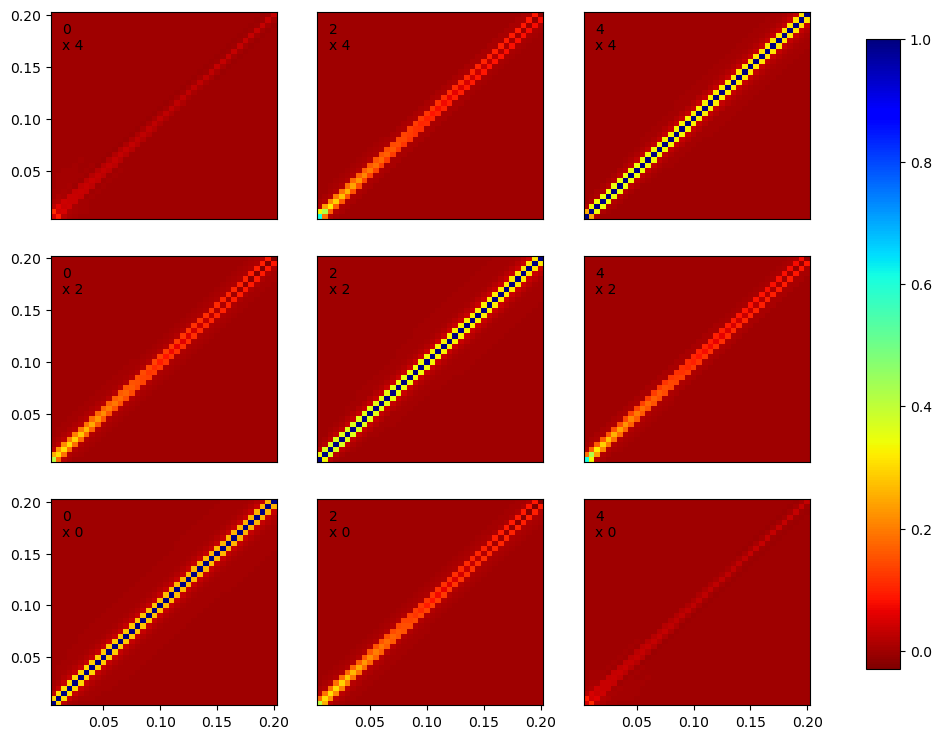

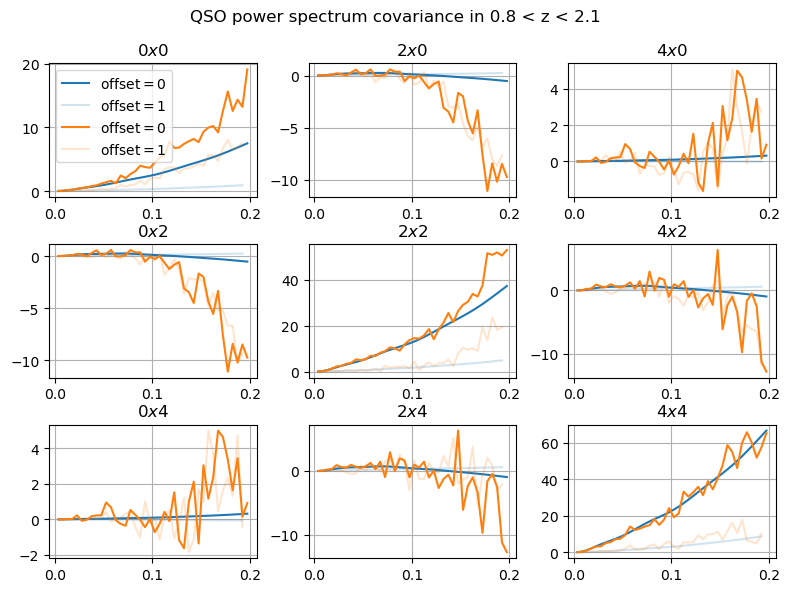

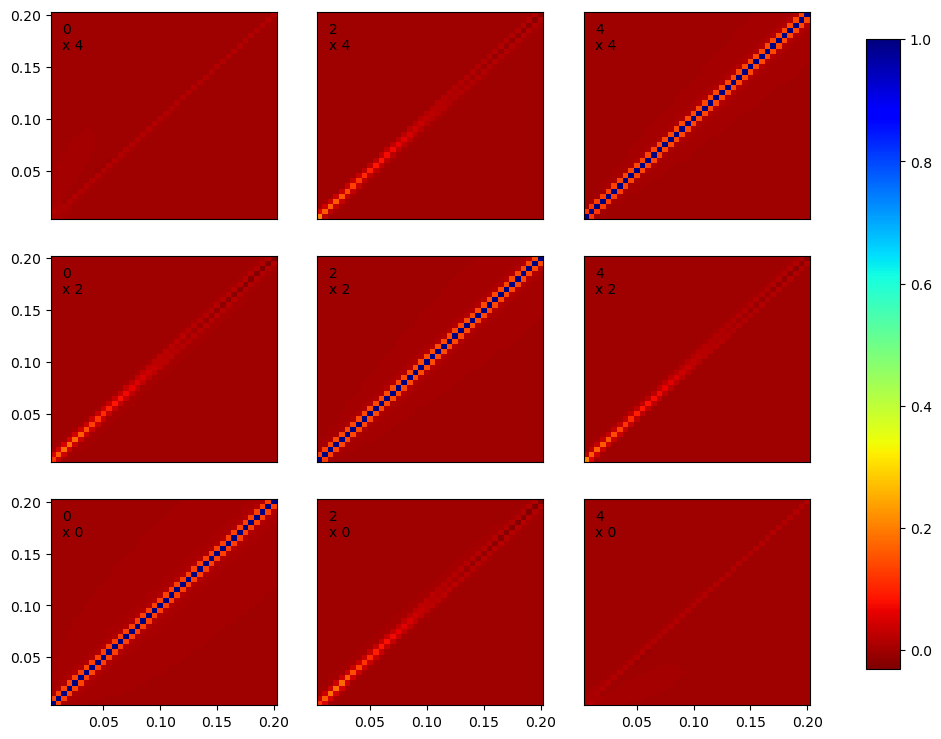

In [5]:
for tracer in ['LRG', 'ELG_LOPnotqso', 'QSO']:
    for zrange in tools.propose_fiducial('zranges', tracer):
        kind = 'mesh2_spectrum'
        region = 'GCcomb'
        fn = tools.get_stats_fn(stats_dir=stats_dir, kind=f'covariance_{kind}', version='holi-v1-altmtl', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock=201)
        covariance_analytic = types.read(fn)
        covariance_analytic = covariance_analytic.at.observable.get(observables='spectrum2', tracers=(tools.get_simple_tracer(tracer),) * 2)
        fn = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='holi-v1-altmtl', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock=201)
        fns = tools.get_stats_fn(stats_dir=stats_dir, kind=kind, version='holi-v1-altmtl', tracer=tracer,
                                zrange=zrange, region=region, weight='default-FKP', imock='*')
        #mocks = [types.read(fn) for fn in fns]
        #sns = [mock.get(ells=0).values('shotnoise').mean() for mock in mocks]
        covariance_mocks = types.cov([types.read(fn) for fn in fns])
        observable = covariance_mocks.observable.select(k=slice(0, None, 5)).select(k=(0., 0.2))
        covariance_analytic = covariance_analytic.at.observable.match(observable)
        covariance_mocks = covariance_mocks.at.observable.match(observable)
        kw = dict(ytransform=lambda x, y: x**4 * y, offset=np.arange(2))
        fig = covariance_analytic.plot_diag(**kw, show=False, color='C0')
        fig.suptitle(f'{tracer} power spectrum covariance in {zrange[0]:.1f} < z < {zrange[1]:.1f}', fontsize=12)
        covariance_mocks.plot_diag(**kw, fig=fig, color='C1', show=True)
        covariance_analytic.plot(corrcoef=True, show=True)